# Workflow Usage Demonstration

This notebook demonstrates three different ways to use the same workflow functions:
1. **Direct Python** - Framework-agnostic, pure Python usage
2. **Pyiron** - Using pyiron_workflow decorators with knowledge graph support
3. **Jobflow** - Using jobflow decorators for workflow management

In [1]:
import matplotlib.pyplot as plt
import numpy as np

## Setup: Common Parameters

These parameters will be used across all three approaches.

In [2]:
# Common simulation parameters
pair_style = "eam/alloy"
pair_coeff = "* * workflows/potentials/Fe_Ack.eam Fe"

## 1. Direct Python Usage

Using the core workflow functions directly without any framework decorators.
This is useful for simple scripts, testing, or when you don't need workflow management.

In [3]:
from workflows.evcurves import calculate_ev_curves as calc_ev_python
from workflows.build import bulk as bulk_python

# Create structure using pure Python
structure = bulk_python('Fe', crystalstructure='bcc', a=2.87, cubic=True)

# Calculate EV curves directly
results = calc_ev_python(
    structure, 
    pair_style, 
    pair_coeff, 
    vol_range=0.01,
    num_of_points=5,
    cores=1
)

print("Python Results:")
print(f"  Bulk modulus: {results['bulk_modulus']:.2f} GPa")
print(f"  Volume range: {results['volume'].min():.3f} - {results['volume'].max():.3f} Å³")

LAMMPS (27 Jun 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (2.8413 2.8413 2.8413)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2 atoms
  read_data CPU = 0.013 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 6.156425
  ghost atom cutoff = 6.156425
  binsize = 3.0782125, bins = 1 1 1
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/alloy, perpetual
      attributes: half, newton on
      pair build: 

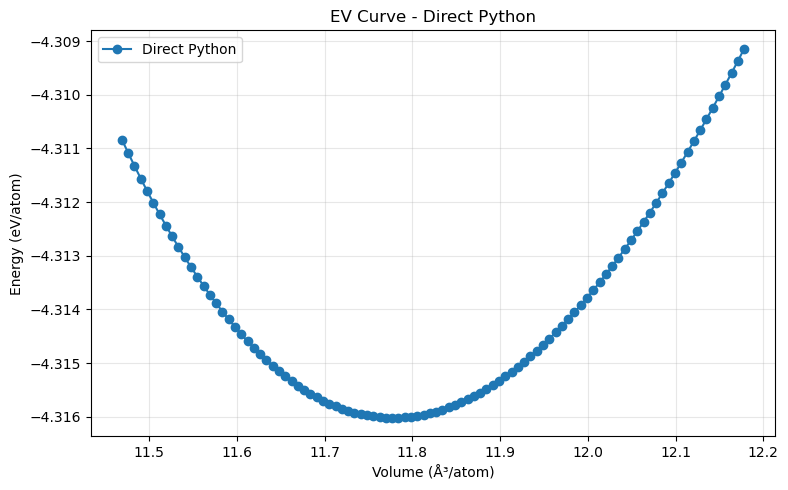

In [4]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(results['volume'], results['energy'], 'o-', label='Direct Python')
plt.xlabel('Volume (Å³/atom)')
plt.ylabel('Energy (eV/atom)')
plt.title('EV Curve - Direct Python')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2. Pyiron Workflow Usage

Using pyiron_workflow decorators with knowledge graph support for metadata tracking.
This enables workflow visualization, execution tracking, and semantic metadata storage.

In [ ]:
from workflows.pyiron.build import bulk as bulk_pyiron
from workflows.pyiron.evcurves import calculate_ev_curves as calc_ev_pyiron
from pyiron_workflow import Workflow
from conceptual_dictionary import ConceptualDict 

# Initialize knowledge graph
cd = ConceptualDict()

# Create workflow
wf = Workflow('ev_demo')

# Build structure with cdict tracking
wf.structure = bulk_pyiron('Fe', crystalstructure='bcc', a=2.87, cubic=True, cdict=cd)

# Calculate EV curves with cdict tracking
wf.ev_curves = calc_ev_pyiron(
    wf.structure, 
    pair_style, 
    pair_coeff, 
    vol_range=0.01,
    num_of_points=5,
    cores=1,
    cdict=cd,
    potential_type='EAM',
    potential_doi='https://doi.org/10.1103/PhysRevB.69.144113'
)

# Execute workflow
pyiron_results = wf.run()

LAMMPS (27 Jun 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (2.8413 2.8413 2.8413)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2 atoms
  read_data CPU = 0.010 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: every = 1 steps, delay = 0 steps, check = yes
  max neighbors/atom: 2000, page size: 100000
  master list distance cutoff = 6.156425
  ghost atom cutoff = 6.156425
  binsize = 3.0782125, bins = 1 1 1
  1 neighbor lists, perpetual/occasional/extra = 1 0 0
  (1) pair eam/alloy, perpetual
      attributes: half, newton on
      pair build: 

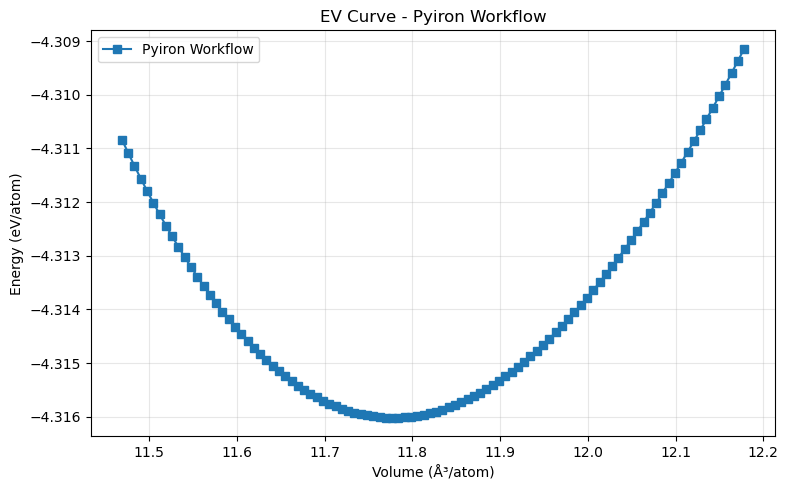

In [8]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(
    pyiron_results['ev_curves__datadict']['volume'], 
    pyiron_results['ev_curves__datadict']['energy'], 
    's-', 
    label='Pyiron Workflow'
)
plt.xlabel('Volume (Å³/atom)')
plt.ylabel('Energy (eV/atom)')
plt.title('EV Curve - Pyiron Workflow')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

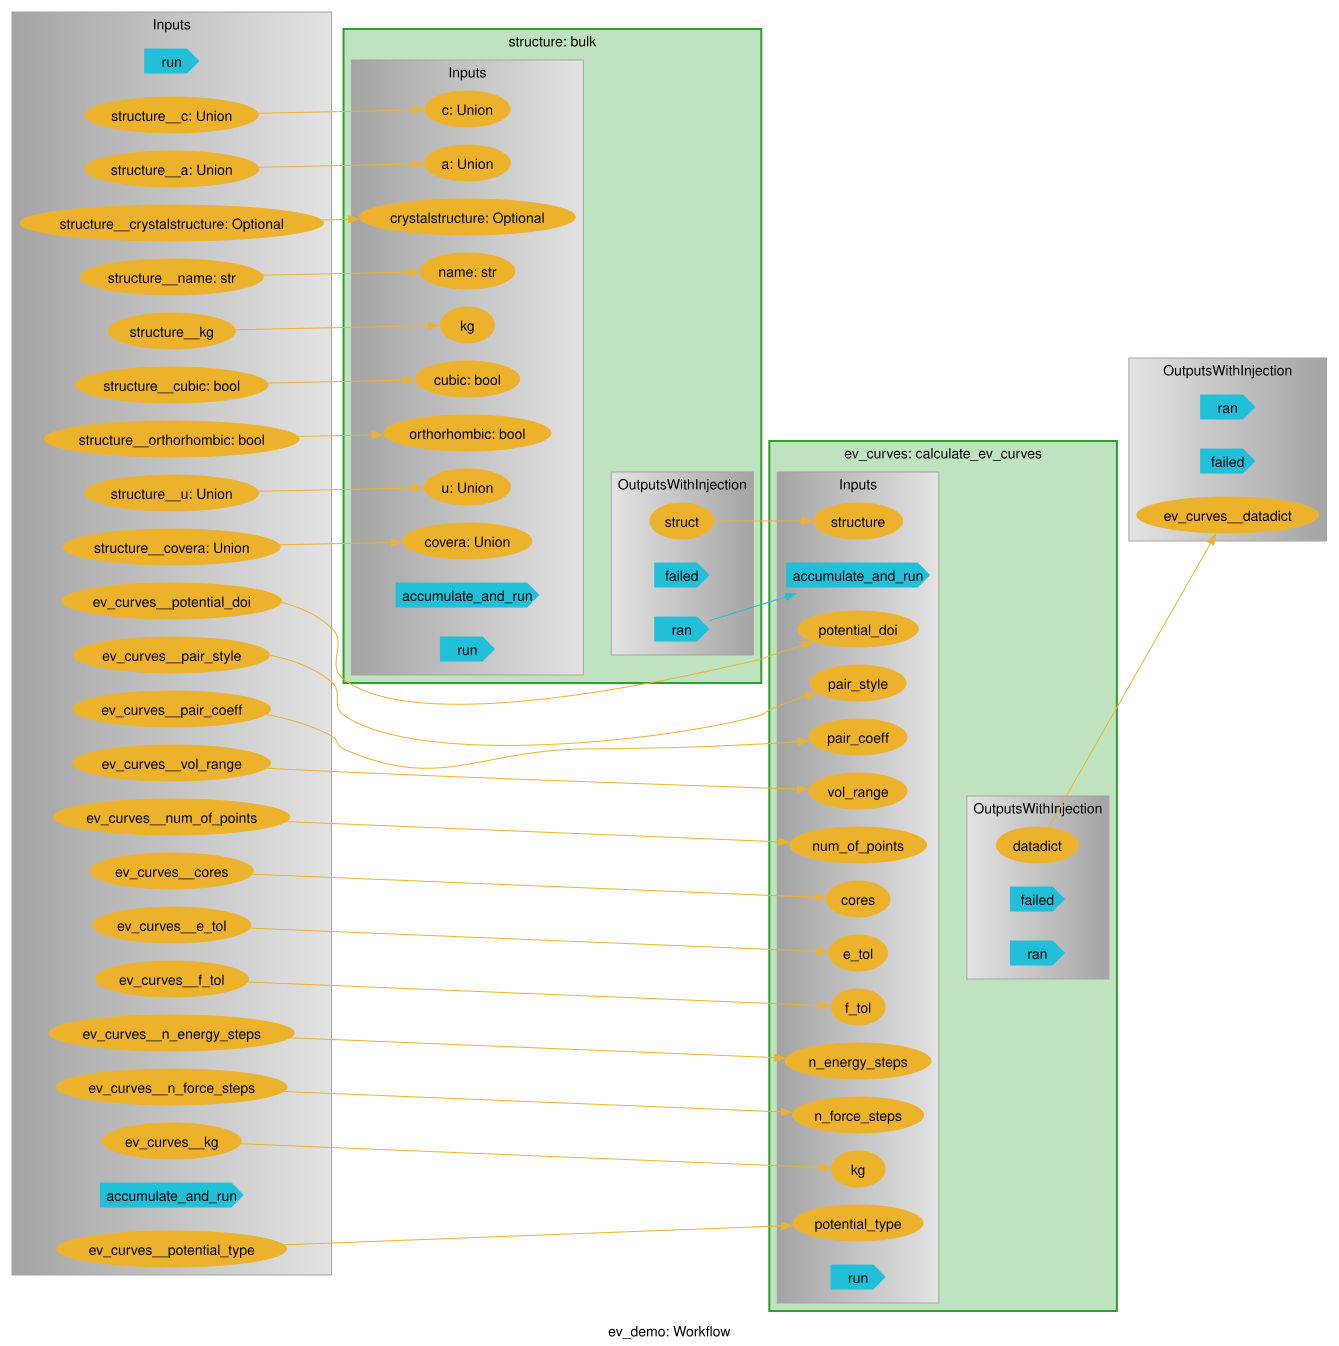

In [9]:
# Visualize workflow graph
wf.draw(rankdir='LR')

In [10]:
# Export knowledge graph
cd.to_yaml('demo_evcurve.yaml')
print("Knowledge graph exported to demo_evcurve.yaml")

Knowledge graph exported to demo_evcurve.yaml


## 3. Jobflow Usage

Using jobflow decorators for distributed workflow execution and job management.
This enables job submission to queuing systems and distributed computing.

In [ ]:
from workflows.jobflow.build import bulk as bulk_jobflow
from workflows.jobflow.evcurves import calculate_ev_curves as calc_ev_jobflow
from jobflow import Flow, run_locally

# Create structure job
structure_job = bulk_jobflow('Fe', crystalstructure='bcc', a=2.87, cubic=True)

# Create EV curves job (depends on structure job)
ev_job = calc_ev_jobflow(
    structure_job.output,  # Use output from previous job
    pair_style,
    pair_coeff,
    vol_range=0.01,
    num_of_points=5,
    cores=1
)

# Create flow
flow = Flow([structure_job, ev_job], name='ev_demo_flow')

# Run flow locally
jobflow_results = run_locally(flow)

# Extract results - jobflow returns dict with job UUIDs as keys
# Each value is a tuple of (job_index, response)
# Get the EV curves job result (it's the second job, index 1)
responses = list(jobflow_results.values())

print("\nJobflow Results:")
print(f"  Bulk modulus: {responses[1][1].output['bulk_modulus']:.2f} GPa")
print(f"  Jobs executed: {len(jobflow_results)}")

2026-01-27 12:24:50,028 INFO Started executing jobs locally
2026-01-27 12:24:50,141 INFO Starting job - bulk (aa00e1d2-30e6-406f-8dad-b5eb9a6bcc59)
2026-01-27 12:24:50,146 INFO Finished job - bulk (aa00e1d2-30e6-406f-8dad-b5eb9a6bcc59)
2026-01-27 12:24:50,147 INFO Starting job - calculate_ev_curves (533090f6-5024-49aa-8303-503e5e4e3302)
LAMMPS (27 Jun 2024)
OMP_NUM_THREADS environment is not set. Defaulting to 1 thread. (src/comm.cpp:98)
  using 1 OpenMP thread(s) per MPI task
Reading data file ...
  orthogonal box = (0 0 0) to (2.8413 2.8413 2.8413)
  1 by 1 by 1 MPI processor grid
  reading atoms ...
  2 atoms
  read_data CPU = 0.011 seconds

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Your simulation uses code contributions which should be cited:
- Type Label Framework: https://doi.org/10.1021/acs.jpcb.3c08419
The log file lists these citations in BibTeX format.

CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE-CITE

Neighbor list info ...
  update: 

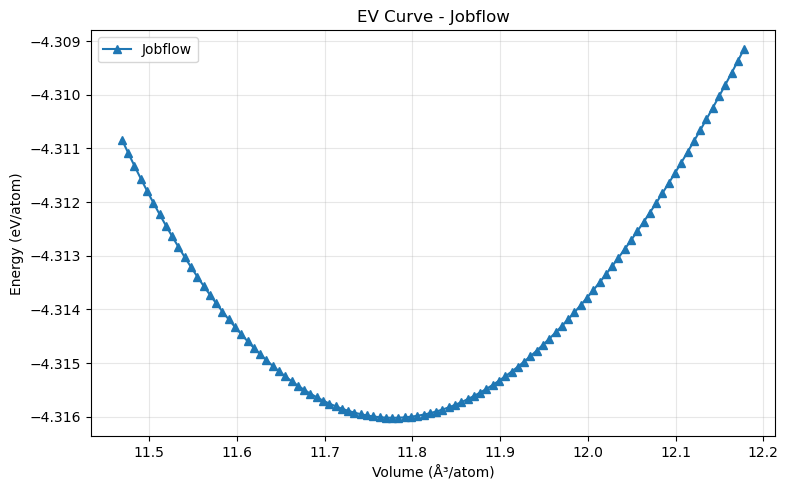

In [6]:
# Plot results
plt.figure(figsize=(8, 5))
plt.plot(
    responses[1][1].output['volume'], 
    responses[1][1].output['energy'], 
    '^-', 
    label='Jobflow'
)
plt.xlabel('Volume (Å³/atom)')
plt.ylabel('Energy (eV/atom)')
plt.title('EV Curve - Jobflow')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()